# Factor Analysis exploratoria con datos NCI60

Este laboratorio estudia perfiles de expresión génica del conjunto NCI60 mediante Factor Analysis. Cada fila representa una observación del conjunto de líneas celulares y las columnas de `X` son variables de expresión. El dataset se consulta desde OpenML (dataset ID 46132).

El código conserva todas las columnas de `X`, imputa valores faltantes con la mediana por variable y estandariza antes del ajuste. No se implementa una selección de genes por varianza, aunque esa decisión aparecía en la descripción anterior.

OpenML entrega además un target cuyo atributo predeterminado se llama `Thioguanine`. Se reserva para colorear y explorar la proyección; no participa en el ajuste de factores. La definición y codificación exactas de ese atributo deben confirmarse en los metadatos del dataset.

El análisis es exploratorio, no un modelo predictivo. Se fijan tres factores como demostración didáctica; el notebook no valida que tres sea el número óptimo.

## Objetivos de aprendizaje

Al finalizar este laboratorio podrás:

- distinguir el objetivo de Factor Analysis del de PCA;
- explicar el papel de los factores latentes, las cargas y la varianza residual;
- interpretar una proyección de líneas celulares sin confundir asociación visual con causalidad;
- proponer cómo comprobar si el número de factores y la estructura hallada son estables.

## Pregunta analítica

¿Puede una representación de pocos factores resumir covariación entre muchas medidas de expresión génica? Los tres factores son una demostración, no una selección estadística validada. El análisis es exploratorio y el target `Thioguanine` solo colorea/describe resultados; no se usa para ajustar Factor Analysis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [8]:
dataset = openml.datasets.get_dataset(46132)
X, y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format='dataframe'
)

print(dataset.name)
print('Forma:', X.shape)
print('Target name:', dataset.default_target_attribute)
print('Target sample:')
print(y.head())
print('\nPrimeras columnas:')
print(X.head())

NCI_60_Thioguanine
Forma: (60, 48)
Target name: Thioguanine
Target sample:
0    5.567880
1    5.323600
2    6.134840
3    6.111710
4    5.755775
Name: Thioguanine, dtype: float64

Primeras columnas:
   ABCA1  ABCA2  ABCA3  ABCA4  ABCA5  ABCA6  ABCA7  ABCA8  ABCA9  ABCA10  ...  \
0   0.37  -0.67   3.78  -1.13   1.71   2.00  -0.24  -1.11  -1.52    0.37  ...   
1  -0.50   0.06  -2.88  -0.38   0.44   3.01  -1.65  -1.33   4.54   -0.65  ...   
2  -2.07   0.80   3.79   3.95   0.26  -1.79  -0.83   0.68  -1.61    0.21  ...   
3   0.38   0.47   2.40  -0.76   0.90   0.73   0.92  -3.08  -1.52    0.53  ...   
4   0.36  -0.14   0.93  -0.42   0.80  -1.25   0.90  -3.89  -1.07    1.56  ...   

   ABCD4  ABCE1  ABCF1  ABCF2  ABCF3  ABCG1  ABCG2  ABCG4  ABCG5  ABCG8  
0  -1.26   1.25   1.62   1.05   0.51  -0.68  -0.03   1.37  -0.19   0.89  
1  -0.29   0.99   1.16   1.07   0.99  -1.56   0.52   0.60  -0.64  -3.10  
2  -0.19  -1.22  -0.65  -1.05  -0.63   3.37   1.31  -2.38   0.05   0.81  
3  -0.86   1.35   

In [13]:
X_sel = X.copy()
X_sel = X_sel.fillna(X_sel.median())
print(f'Genes usados: {X_sel.shape[1]}')
print(X_sel.head())

scaler = StandardScaler()
X_std = scaler.fit_transform(X_sel)

Genes usados: 48
   ABCA1  ABCA2  ABCA3  ABCA4  ABCA5  ABCA6  ABCA7  ABCA8  ABCA9  ABCA10  ...  \
0   0.37  -0.67   3.78  -1.13   1.71   2.00  -0.24  -1.11  -1.52    0.37  ...   
1  -0.50   0.06  -2.88  -0.38   0.44   3.01  -1.65  -1.33   4.54   -0.65  ...   
2  -2.07   0.80   3.79   3.95   0.26  -1.79  -0.83   0.68  -1.61    0.21  ...   
3   0.38   0.47   2.40  -0.76   0.90   0.73   0.92  -3.08  -1.52    0.53  ...   
4   0.36  -0.14   0.93  -0.42   0.80  -1.25   0.90  -3.89  -1.07    1.56  ...   

   ABCD4  ABCE1  ABCF1  ABCF2  ABCF3  ABCG1  ABCG2  ABCG4  ABCG5  ABCG8  
0  -1.26   1.25   1.62   1.05   0.51  -0.68  -0.03   1.37  -0.19   0.89  
1  -0.29   0.99   1.16   1.07   0.99  -1.56   0.52   0.60  -0.64  -3.10  
2  -0.19  -1.22  -0.65  -1.05  -0.63   3.37   1.31  -2.38   0.05   0.81  
3  -0.86   1.35   1.40   0.70   0.56  -1.46  -2.78  -1.86  -0.49   3.18  
4   1.54   1.12   1.92   0.20   1.02   0.47   0.59   1.61   0.06   0.27  

[5 rows x 48 columns]


In [15]:
fa = FactorAnalysis(n_components=3, random_state=42, max_iter=1000)
scores = fa.fit_transform(X_std)

print('Varianza residual de cada variable estimada por el modelo:')
print(np.round(fa.noise_variance_, 4)[:10])
print(f'\nNúmero de factores: {fa.n_components}')
print(f'Cantidad de genes usados: {X_sel.shape[1]}')

n_factors = fa.n_components
factor_df = pd.DataFrame(scores, index=X_sel.index, columns=[f'Factor {i+1}' for i in range(n_factors)])
factor_df['Thioguanine'] = y.reset_index(drop=True)
factor_df.head()

Varianza residual de cada variable estimada por el modelo:
[0.9074 0.7434 0.5513 0.9632 0.7541 0.7258 0.8038 0.6068 0.449  0.862 ]

Número de factores: 3
Cantidad de genes usados: 48


,Factor 1,Factor 2,Factor 3,Thioguanine
0,-0.469997,-0.684038,-0.228907,5.567880
1,-1.306537,-0.002122,-0.584469,5.323600
2,1.267694,0.421603,1.230790,6.134840
3,-0.954826,-0.990337,1.086074,6.111710
4,-0.574303,-0.841201,-0.340594,5.755775


In [16]:
loadings = fa.components_.T
loading_df = pd.DataFrame(loadings, index=X_sel.columns, columns=[f'Factor {i+1}' for i in range(n_factors)])

print('Loadings del modelo de Factor Analysis (primeros 10 genes):')
display(loading_df.head(10).round(3))

for i in range(n_factors):
    factor_col = f'Factor {i+1}'
    top_genes = loading_df[factor_col].abs().sort_values(ascending=False).head(5)
    print(f'\n{factor_col}: genes con mayor carga')
    print(top_genes.round(3).to_string())

Loadings del modelo de Factor Analysis (primeros 10 genes):


,Factor 1,Factor 2,Factor 3
ABCA1,-0.065,-0.185,-0.228
ABCA2,0.492,-0.057,-0.109
ABCA3,0.453,-0.255,0.419
ABCA4,0.127,0.013,0.144
ABCA5,-0.249,0.361,0.231
ABCA6,-0.278,0.434,0.098
ABCA7,-0.047,-0.420,0.119
ABCA8,0.435,0.443,-0.080
ABCA9,-0.138,0.691,-0.228
ABCA10,0.000,-0.235,0.279



Factor 1: genes con mayor carga
ABCC12    0.938
ABCD2     0.872
ABCF2     0.513
ABCE1     0.498
ABCB8     0.496

Factor 2: genes con mayor carga
ABCA9    0.691
ABCB5    0.655
ABCE1    0.652
ABCC2    0.612
ABCD1    0.592

Factor 3: genes con mayor carga
ABCC4     0.563
ABCC11    0.511
ABCB2     0.442
ABCA3     0.419
ABCA12    0.401


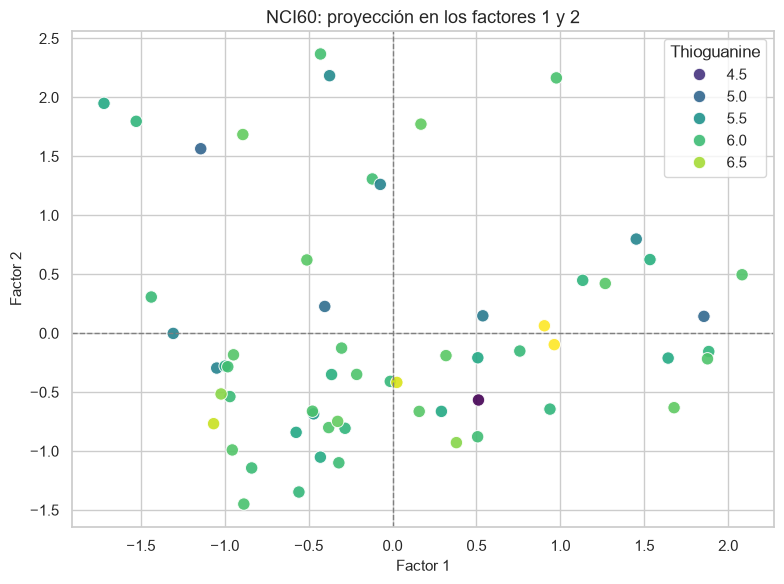

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=factor_df,
    x='Factor 1',
    y='Factor 2',
    hue='Thioguanine',
    palette='viridis',
    s=80,
    alpha=0.9,
    ax=ax,
)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('NCI60: proyección en los factores 1 y 2')
plt.tight_layout()

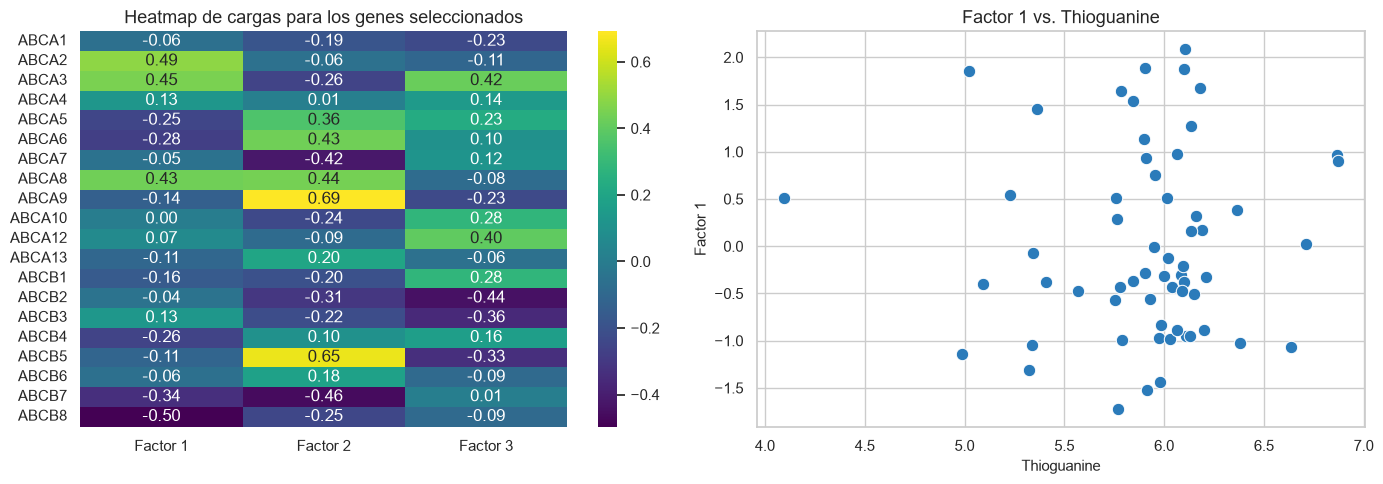

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Representación de la matriz de cargas para los primeros factores
heat = loading_df.iloc[:20, :].copy()
sns.heatmap(heat, cmap='viridis', annot=True, fmt='.2f', cbar=True, ax=axes[0])
axes[0].set_title('Heatmap de cargas para los genes seleccionados')

# Gráfico del factor 1 frente a la respuesta Thioguanine
sns.scatterplot(data=factor_df, x='Thioguanine', y='Factor 1', s=80, color='#2b7bba', ax=axes[1])
axes[1].set_title('Factor 1 vs. Thioguanine')
axes[1].set_xlabel('Thioguanine')
axes[1].set_ylabel('Factor 1')

plt.tight_layout()

## Lectura de cargas factoriales

Las cargas describen la asociación de cada variable con los factores estimados; la orientación del signo puede invertirse sin cambiar la solución. El listado de genes con mayor carga es descriptivo y no basta para asignar una función biológica.

En la tabla y el heatmap, busca si varias variables presentan magnitudes altas en un mismo factor y si aparecen patrones compartidos entre factores. Antes de hablar de módulos o procesos celulares, verifica la anotación de los genes y la estabilidad del patrón al cambiar el número de factores o la muestra.

El código muestra los genes con las mayores cargas absolutas observadas en esta ejecución. No se ha incorporado una base de anotaciones funcionales, de modo que las cargas no justifican por sí solas una interpretación de vía biológica.

## Interpretación y limitaciones

Factor Analysis representa la covariación entre variables mediante factores latentes y una varianza residual específica por variable (`noise_variance_`). A diferencia de PCA, no busca únicamente direcciones que maximicen la varianza total: parte de un modelo de factores comunes.

Los scores ubican cada observación en el espacio latente y los loadings describen asociaciones variables-factor. La proyección coloreada por `Thioguanine` es exploratoria; no demuestra que ese atributo cause los patrones observados ni que los factores representen procesos biológicos identificados.

Este ejemplo fija tres factores y no incluye una evaluación de factorabilidad, rotación ni estabilidad. Por ello, el resultado es una demostración de interpretación, no una solución validada para análisis biomédico.

## Conclusiones

Resume qué patrones aparecen en loadings y scores y qué parte permanece como varianza residual específica. Separa las observaciones descriptivas de las hipótesis biológicas: para dar nombres funcionales a factores hacen falta anotaciones y validación externa. El número de factores mostrado es ilustrativo.

## Ejercicios propuestos

1. **Conceptual:** explica qué estructura compartida intenta representar Factor Analysis y en qué difiere de PCA.
2. **Implementación:** compara soluciones con distinto número de factores y organiza los log-likelihoods de ajuste sin usar el target para seleccionarlos.
3. **Experimentación:** revisa cómo cambian los loadings principales al variar el número de factores.
4. **Análisis:** describe qué se puede y qué no se puede inferir del gráfico coloreado por `Thioguanine`.
5. **Desafío:** propone cómo evaluarías la estabilidad de los factores y qué anotaciones externas necesitarías antes de asignarles una interpretación biológica.

## Referencias

- [Factor Analysis en scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FactorAnalysis.html)
- [Registro NCI60 consultado en OpenML, dataset 46132](https://www.openml.org/d/46132)

La referencia primaria del conjunto y sus condiciones de uso deben confirmarse en los metadatos enlazados antes de reutilizarlo fuera de este laboratorio.